In [233]:
import pickle
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import itertools

from sklearn.metrics import r2_score
from vebir.absorbance_estimators.cross_validation import BlockCV 
from vebir.absorbance_estimators.vibes import VibeSpec
from vebir.interference_models.pca import pca, loo_pca

from vebir.utils.help_functions import ebs_help_fun
import time

In [234]:
wn = pd.read_parquet("../data/teflon/SO4/spectra.parquet").columns.astype(float)

with open("../data/spectrabase/ref_dict.pkl", "rb") as f:
    ref_prof = pickle.load(f)
    
gt = ref_prof["Ammonium sulfate"]

In [247]:
with open("../data/teflon/lab_samples/vibes/PB_c_elbo_tau_elbo_mit_10000.pkl", "rb") as f:
    res = pickle.load(f)

In [236]:
with open("../data/teflon/lab_samples/ebs/PB_c_bcv_tau_bcv.pkl", "rb") as f:
    res = pickle.load(f)

In [248]:
X = np.array([i["absorbance"] for i in res])
X = (X.T / np.max(X, axis=1)).T

In [249]:
loads = pd.read_csv("../data/teflon/lab_loadings.csv",index_col=0,skiprows=4,dtype={"sample": str},)
loads.index = loads.index + ".dpt"

In [250]:
np.unique(labs)

array(['1-Docosanol', '1-Docosanol|Adipic Acid',
       '1-Docosanol|Adipic Acid|Suberic Acid', '1-Docosanol|Suberic Acid',
       'Arac.', 'Malonic Acid', 'SO4', 'Suberic Acid', 'Tric.', 'fruc.',
       'gluc.', 'levo.'], dtype=object)

In [251]:
labs = np.repeat(None, X.shape[0])
for i in range(X.shape[0]):
    labs[i] = loads.loc[res[i]["sample_id"]]["compounds"]
    if labs[i] == "Ammonium sulfate":
        labs[i] = "SO4"
        
    if labs[i] == "D-Glucose":
        labs[i] = "gluc."
        
    if labs[i] == "fructose":
        labs[i] = "fruc."
        
    if labs[i] == 'levoglucosan':
        labs[i] = "levo."
        
    if labs[i] == '12-Tricosanone':
        labs[i] = "Tric."
        
    if labs[i] == 'Arachidyl Dodecanoate':
        labs[i] = "Arac."




In [252]:
cvals = []
for i in range(SO4.shape[0]):
    c = res[i]["c"]
    cvals.append(c)

{'whiskers': [<matplotlib.lines.Line2D at 0x213308d7200>,
 'caps': [<matplotlib.lines.Line2D at 0x213308d67e0>,
 'boxes': [<matplotlib.lines.Line2D at 0x213308d7dd0>],
 'medians': [<matplotlib.lines.Line2D at 0x213308dd250>],
 'fliers': [<matplotlib.lines.Line2D at 0x213308df6e0>],
 'means': []}

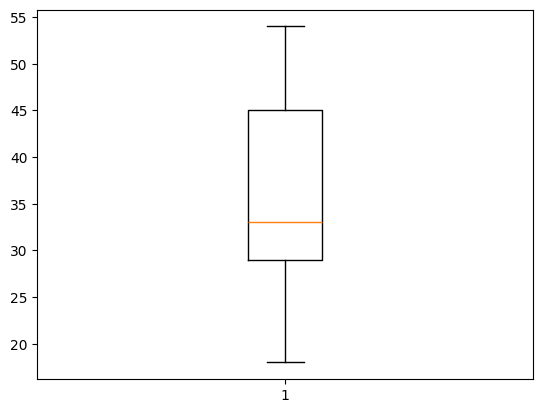

In [253]:
plt.boxplot(cvals)

In [254]:
np.min(cvals)

np.int64(18)

In [255]:
SO4 =X[labs == "SO4"]

In [256]:
cors = []
for i in range(SO4.shape[0]):
    break

In [257]:
np.mean([np.corrcoef(np.interp(gt[:,0],wn, SO4[i]), gt[:,1])[0,1] for i in range(SO4.shape[0])])

np.float64(0.9775074661673567)

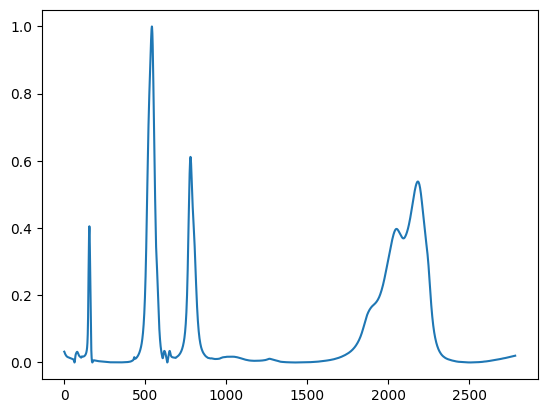

In [98]:
plt.plot(SO4[45,:])

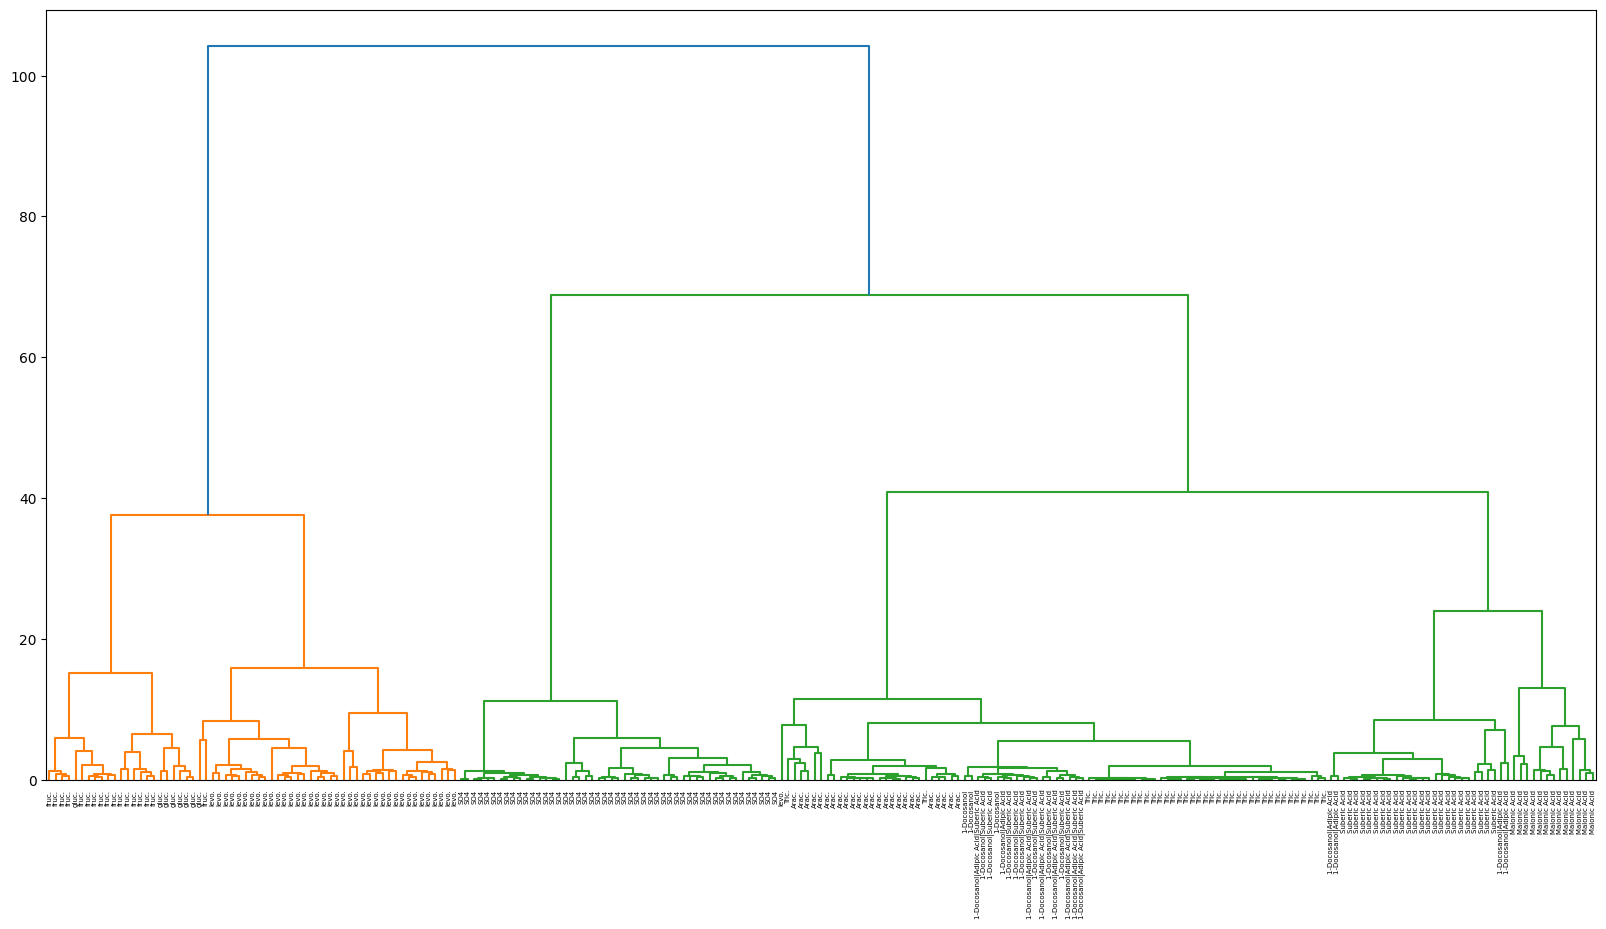

In [159]:
# Optional: visualize
plt.figure(figsize=(20, 10))
dendrogram(Z,labels=labs)
plt.savefig("../data/temp/dendrogram.png")
plt.show()

In [77]:
np.unique(labs)

array(['1-Docosanol', '1-Docosanol|Adipic Acid',
       '1-Docosanol|Adipic Acid|Suberic Acid', '1-Docosanol|Suberic Acid',
       '12-Tricosanone', 'Arachidyl Dodecanoate', 'D-Glucose',
       'Malonic Acid', 'SO4', 'Suberic Acid', 'fructose', 'levoglucosan'],
      dtype=object)

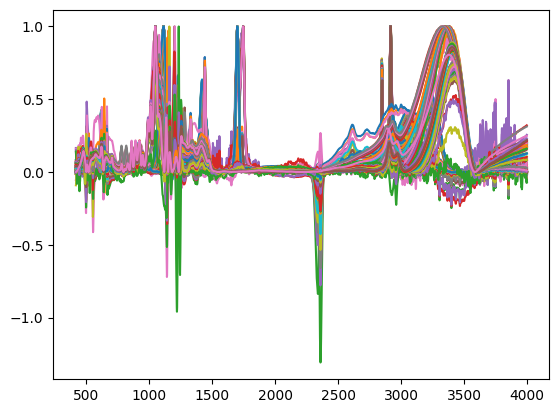

In [74]:
for i in range(X.shape[0]):
    plt.plot(wn, X[i], label=f"sample {i}")

In [75]:
from scipy.spatial.distance import pdist
from scipy.cluster.hierarchy import linkage, dendrogram

# Step 1: pairwise distances
D = pdist(X, metric='euclidean')

# Step 2: Ward linkage
Z = linkage(D, method='ward')

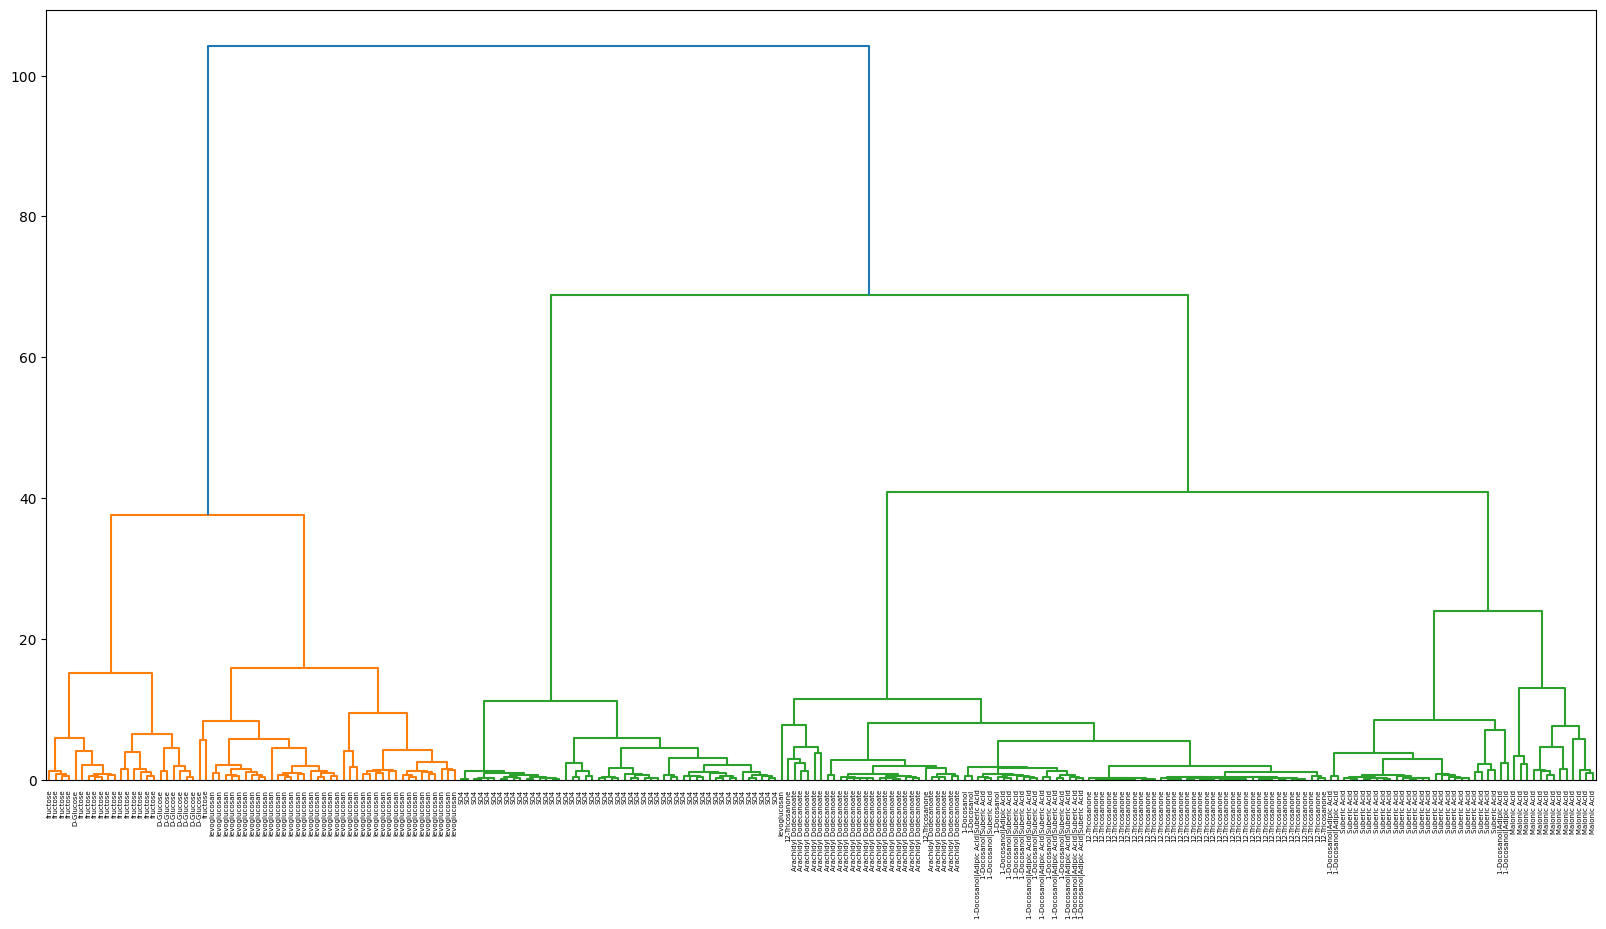

In [ ]:
aa

In [6]:
with open("../data/preprocessed/teflon/raw_spectra_dict.pkl", "rb") as f:
    spec = pickle.load(f)

In [12]:
df = pd.concat([spec[i]["raw"] for i in spec])
    

In [13]:
df.to_parquet("../data/teflon/lab_samples/spectra.parquet")

In [9]:
with open("../data/preprocessed/teflon/raw_spectra_dict.pkl", "rb") as f:
    raw_spectra_dict = pickle.load(f)
    
with open("../data/preprocessed/teflon/blanks_dict.pkl", "rb") as f:
        blanks_dict = pickle.load(f)
        
sigma = 0 
tau = 0.1
c = 47
chat_cv = 47


YSO4 = pd.read_parquet("../data/teflon/SO4/spectra.parquet")
Z = pd.read_parquet("../data/teflon/SO4/blanks.parquet")
Z = np.array(Z)
y = YSO4.iloc[0,:].values
mu, _, _, W = pca(Z)

In [ ]:
# 

In [46]:
with open(f"../data/corrections/teflon/map/pb/sigma.pkl", "rb") as f:
    res_old = pickle.load(f)
res_old = res_old["Ammonium sulfate"]

In [56]:
with open(f"../data/temp/sigma.pkl", "rb") as f:
    res_old = pickle.load(f)
res_old = res_old["Ammonium sulfate"]

In [68]:
def map_help_fun(args):
    y, mu, W, tau, c, loss, sample_id = args
    
    if tau is None:
        tau_grid = 0.1 * np.power(2.0, np.arange(-2, 3))    
    
    else:
        tau_grid = [tau]
        
    if c is None:
        c_grid = np.arange(1, W.shape[1], 1)
    
    else:
        c_grid = [c]    
        
    sigma_grid = [1e-6, 1e-5, 1e-4, 1e-3, 1e-2]
    
    mod = BlockCV(total_wavenums=y.shape[0], tau_grid=tau_grid,c_grid=c_grid,sigma_grid=sigma_grid,loss = loss)
    start = time.time()
    mod.compute_cv_errors(y, mu, W)
            
    z,x = mod.map_solver.solve(y, mu, W[:, :mod.c], mod.mit)
    
    end = time.time()

    res = {
        "sample_id": sample_id,
        "absorbance": y-z,
        "time": end - start,
        "sigma": mod.sigma,
        "tau":mod.tau,
        "c": mod.c,
        "x": x,
    }

    return res

In [79]:
args = (YSO4.iloc[5,:].values, mu, W, 0.1, 47, "PB", YSO4.index[1])

In [80]:
mod =  map_help_fun(args)

In [84]:
mod

{'sample_id': '01020.dpt',
 'absorbance': array([0.00175254, 0.00172157, 0.00166207, ..., 0.00244559, 0.00245554,
        0.0024619 ], shape=(2785,)),
 'time': 8.382770776748657,
 'sigma': 0.001,
 'tau': 0.1,
 'c': 47,
 'x': array([ 1.25557815, -5.0044799 ,  3.0980394 , -4.25493777, -0.05494054,
        -5.02300341,  4.43060914,  0.70482997, 14.01543998, -8.10841546,
         3.7006417 ,  0.60957851,  3.35951537,  0.62261141,  0.96471241,
         1.83802994,  0.71067744,  0.20819669,  0.42667442, -0.17153678,
        -0.08984821,  0.17521774,  1.52846689,  2.43905069,  0.27500481,
         0.21954632, -0.45316022, -0.02401662,  0.24563345, -0.23012048,
        -0.09293158, -0.40257062, -0.05965236,  0.21652834,  0.1065409 ,
        -0.1230632 ,  0.14118033,  0.06186759,  0.15535493,  0.04865549,
         0.06535571,  0.09310251, -0.02786009,  0.03127522,  0.07890383,
        -0.0438022 ,  0.05704089])}

In [81]:
mod["absorbance"] - res_old[1]["absorbance"]

array([-0.00310838, -0.00274994, -0.00200883, ...,  0.00077105,
        0.00078665,  0.00079358], shape=(2785,))

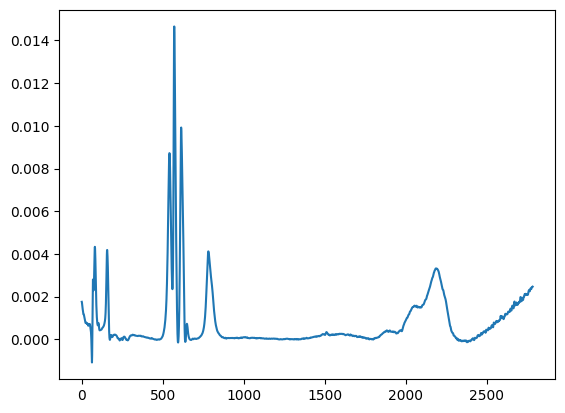

In [82]:
plt.plot(mod["absorbance"])
#plt.plot(res_old[1]["absorbance"])

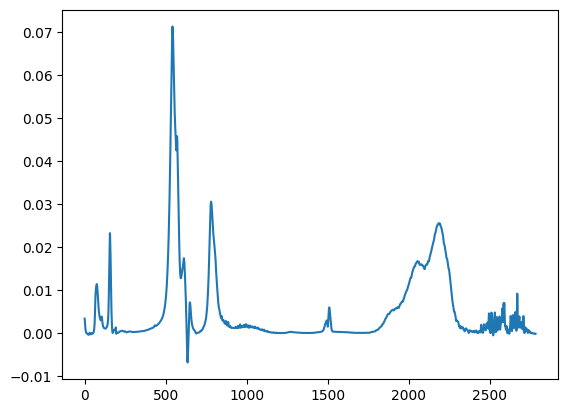

In [ ]:
#def map_help_fun(args):
#     y, mu, W, tau, c, loss, sample_id = args
    
#     if tau is None:
#         tau_grid = 0.1 * np.power(2.0, np.arange(-2, 3))    
    
#     else:
#         tau_grid = [tau]
        
#     if c is None:
#         c_grid = np.arange(1, W.shape[1], 1)
    
#     else:
#         c_grid = [c]    
    
#     sigma_start = 0.0001
#     max_num_steps = -(np.log(np.finfo(float).eps / 0.0001) / np.log(2)).astype(int)
#     sigma_grid = [sigma_start/2, sigma_start, sigma_start*2]
#     sigma_grid = [0.0001,0.001,0.01]
#     mod = BlockCV(total_wavenums=y.shape[0], tau_grid=tau_grid,c_grid=c_grid,sigma_grid=sigma_grid,loss = loss)
    
#     start = time.time()
#     mod.compute_cv_errors(y, mu, W)
#     # num_steps = 2
    
#     # while num_steps < max_num_steps:
    
#     #     if mod.sigma == max(mod.sigma_grid):
#     #         mod.sigma_grid.append(2 * max(mod.sigma_grid))
#     #         mod.cv_errs = np.pad(mod.cv_errs, ((0, 0), (0, 0), (0, 1)), constant_values=np.nan)
#     #         mod.compute_cv_errors(y, mu, W)
            
#     #     elif mod.sigma == min(mod.sigma_grid):
#     #         mod.sigma_grid.insert(0, 0.5 * min(mod.sigma_grid))
#     #         mod.cv_errs = np.pad(mod.cv_errs, ((0, 0), (0, 0), (1,0)), constant_values=np.nan)
#     #         mod.compute_cv_errors(y, mu, W)
            
#     #     else:
#     #         break
            
#     #     num_steps += 1
        
#     #     print(num_steps)
            
#     z,x = mod.map_solver.solve(y, mu, W[:, :mod.c], mod.mit)
    
#     end = time.time()

#     res = {
#         "sample_id": sample_id,
#         "absorbance": y-z,
#         "time": end - start,
#         "sigma": mod.sigma,
#         "tau":mod.tau,
#         "c": mod.c,
#         "x": x,
#     }

#     return res

In [50]:
mod["sigma"]

0.0512

In [29]:
n = -(np.log(np.finfo(float).eps / 0.0001) / np.log(2)).astype(int)

In [30]:
n

np.int64(38)

In [27]:
np.power(2,n.astype(float)) * 0.0001

np.float64(3.637978807091713e-16)

In [24]:
np.finfo(float).eps

np.float64(2.220446049250313e-16)

In [3]:
with open(f"../data/corrections/teflon/veb/pb/sigma_tau.pkl", "rb") as f:
    res_old = pickle.load(f)
res_old = res_old["Ammonium sulfate"]

In [4]:
print(np.unique([res_old[i]["d"].shape[0] for i in range(len(res_old))]))
tau_old = [res_old[i]["tau"] for i in range(len(res_old))]
sigma_old = [res_old[i]["sigma_hat"] for i in range(len(res_old))]

[47]


In [5]:
with open(f"../data/teflon/SO4/vibes/PB_c_loo_tau_elbo_mit_10000.pkl", "rb") as f:
    res = pickle.load(f)

In [6]:
print(np.unique([res[i]["d"].shape[0] for i in range(len(res))]))
tau = [res[i]["tau"] for i in range(len(res))]
sigma = [res[i]["sigma"] for i in range(len(res))]

[47]


In [7]:
YSO4 = pd.read_parquet("../data/teflon/SO4/spectra.parquet")
Z = pd.read_parquet("../data/teflon/SO4/blanks.parquet")
Z = np.array(Z)
y = YSO4.iloc[0,:].values

In [8]:
mu, _, _, W = pca(Z)

In [9]:
from sklearn.linear_model import LinearRegression, Ridge

In [10]:
reg_mod = LinearRegression(fit_intercept=False)

In [11]:
reg_mod.fit(W,y)

LinearRegression(fit_intercept=False)

In [12]:
def map_als(y, mu, W, tau, sigma, mit=100, verbose=False):
    if sigma == 0:
        reg_mod = LinearRegression(fit_intercept=False)

    else:
        reg_mod = Ridge(fit_intercept=False, alpha=sigma / 2, solver="svd")

    w = np.repeat(tau, y.shape[0])

    iterator = range(mit)
    iterator = tqdm(iterator) if verbose else iterator

    for i in iterator:
        reg_mod.fit(W, y - mu, sample_weight=w)
        z = mu + reg_mod.predict(W)
        wold = w
        w = np.repeat(tau, y.shape[0])
        w[y - z < 0] = 1 - tau
        if np.all(wold == w):
            break
        if verbose:
            print(i, end=" \r")

    x = reg_mod.coef_

    return z, x

In [15]:
import time

In [18]:
t0 = time.time()
map_als(y, mu, W, tau = 0.1, sigma=0.0001, mit=100, verbose=False)
t1 = time.time()

In [19]:
t1 - t0

0.0632627010345459

In [27]:
from tqdm import tqdm

In [28]:
res = []
for i in tqdm(range(YSO4.shape[0])):
    y = YSO4.iloc[i,:].values
    args = (y, mu, W, None, None, "ALS", YSO4.index[i])
    out = ebs_help_fun(args)
    res.append(out)

100%|██████████| 49/49 [09:38<00:00, 11.81s/it]


In [30]:
with open(f"../data/teflon/SO4/ebs/ALS_c_bcv_tau_bcv.pkl", "rb") as f:
    res_old = pickle.load(f)

In [32]:
res_old[0]

{'sample_id': '01012.dpt',
 'absorbance': array([-0.00155741, -0.00180509, -0.00242527, ..., -0.00181349,
        -0.00184682, -0.00187122], shape=(2785,)),
 'time': 60916.74949979782,
 'sigma': 0,
 'tau': np.float64(0.025),
 'c': np.int64(4),
 'x': array([ 1.8945958 , -4.67719263, -4.63291164,  1.3275943 ])}

In [38]:
np.array([np.all(res[i]["absorbance"] == res_old[i]["absorbance"]) for i in range(len(res))])

array([ True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True])

In [73]:
mod = BlockCV(total_wavenums=y.shape[0], tau_grid=[0.1],c_grid=[5,15,20,25],sigma_grid=[0.00001,0.0001,0.001],) 

In [74]:
mod.compute_cv_errors(y, mu, W)

In [75]:
mod.c

5

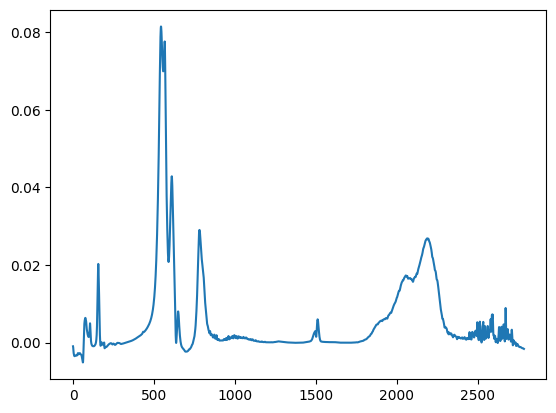

In [76]:
plt.plot(y-mod.map_solver.solve(y, mu, W[:, :mod.c], mod.mit)[0])

In [36]:
#YSO4_old = raw_spectra_dict["Ammonium sulfate"]["raw"]
#YSO4 = pd.read_csv("../data/teflon/SO4/spectra.csv", index_col=0)
#print(np.all(YSO4.columns.astype(float) == YSO4_old.columns.astype(float)))

In [39]:
# #CV : fixed
# tau_grid = [0.1]
# c_grid = [chat_cv]

# #CV : tau
# tau_grid = 0.1 * np.power(2.0, np.arange(-2, 3))
# c_grid = [chat_cv]

# #CV: c
# c_grid = np.arange(1, 54, 1)
# tau_grid = [tau]

# #CV: c, tau
# c_grid = np.arange(1, 54, 1)
# tau_grid = 0.1 * np.power(2.0, np.arange(-2, 3))

# mod = BlockCV(total_wavenums=y.shape[0], tau_grid=tau_grid,c_grid=c_grid,sigma_grid=[sigma],)
# mod.compute_cv_errors(y, mu, W)
# x,z = mod.map_solver.solve(y, mu, W[:, :mod.c], mod.mit)

In [41]:
import time

In [42]:
def map_help_fun(args):
    y, mu, W, tau, c, loss, sample_id = args
    
    if tau is None:
        tau_grid = 0.1 * np.power(2.0, np.arange(-2, 3))    
    
    else:
        tau_grid = [tau]
        
    if c is None:
        c_grid = np.arange(1, W.shape[1], 1)
    
    else:
        c_grid = [c]    
    

    sigma_start = 0.0001
    sigma_grid = [sigma_start/2, sigma_start, sigma_start*2]

    mod = BlockCV(total_wavenums=y.shape[0], tau_grid=tau_grid,c_grid=c_grid,sigma_grid=sigma_grid,loss = loss)
    start = time.time()
    mod.compute_cv_errors(y, mu, W)
    
    if mod.sigma == max(mod.sigma_grid):
        mod.sigma_grid.append(2 * max(mod.sigma_grid))
        mod.cv_errs = np.pad(mod.cv_errs, ((0, 0), (0, 0), (0, 1)), constant_values=np.nan)
        mod.compute_cv_errors(y, mu, W)
        print(mod.sigma_grid)
    
    elif mod.sigma == min(mod.sigma_grid):
        print(1)
        
    
    
    
    return mod
    
    
    z,x = mod.map_solver.solve(y, mu, W[:, :mod.c], mod.mit)
    
    end = time.time()

    res = {
        "sample_id": sample_id,
        "absorbance": y-z,
        "time": end - start,
        "sigma": 0,
        "tau":mod.tau,
        "c": mod.c,
        "x": x,
    }

    return res


In [ ]:
args = (YSO4.iloc[0,:].values, mu, W, 0.1, 47, "PB", YSO4.index[0])
mod =  map_help_fun(args)

[5e-05, 0.0001, 0.0002, 0.0004]


In [28]:
mod.sigma_grid

[5e-05, 0.0001, 0.0002, 0.0004]

In [29]:
mod.cv_errs

array([[[26.32853473, 23.67743977, 17.69092753,         nan]]])